<a href="https://colab.research.google.com/github/PatrickOdilonOgue/-automotive-data-analysis-Python-/blob/Master/Unsupervised_ML_Projekt_bus_%2C_van_or_car_von_Patrick.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ML-Projekt: “Prospect Auto – Unsupervised Learning Ansatz”**



In dieser alternativen Projektvariante entwickeln wir ein automatisches Erkennungs- und Gruppierungssystem auf Basis unüberwachter Lernverfahren (Unsupervised Learning). Ziel ist es, die in den Silhouetten von Fahrzeugen enthaltenen geometrischen Merkmale zu analysieren und natürliche Gruppen (Cluster) in den Daten zu identifizieren – ganz ohne vorher bekannte Klassenlabels wie Bus, Car oder Van.

Daten und Merkmale
Die Datengrundlage bilden 18 extrahierte geometrische Merkmale, darunter:

*   Compactness: Misst die Dichte der Kontur im Verhältnis zu ihrer Fläche
*   Circularity: Beurteilt die Ähnlichkeit mit einem perfekten Kreis
*   Elongatedness: Bezeichnet den Grad der Streckung des Objekts.
*   pr.axis_aspect_ratio: Das Verhältnis der Länge zur Breite der Ellipse, die das Objekt approximiert.
*   Hollows_ratio: Misst das Vorhandensein von Vertiefungen oder Hohlräumen in der Form.
*   Distance_circularity: Maß für die Abweichung.
*   Max.length_aspect_ratio : Verhältnis der maximalen Abmessungen.
*   Scatter_ratio. : Streuung der Punkte

Ziel
Ohne Vorwissen über die Klassen möchten wir gemeinsame Strukturen in den Daten erkennen, indem wir Fahrzeuge mit ähnlichen geometrischen Eigenschaften in Gruppen clustern. Dabei gehen wir davon aus, dass unterschiedliche Fahrzeugtypen verschiedene Muster in den Daten aufweisen.

Vorgehensweise


```
1-Datenvorverarbeitung:
  *Prüfung auf fehlende Werte und Ausreißer
  *Skalierung/Nomalisierung der Merkmale (z. B. mit StandardScaler oder MinMaxScaler)
```
```
2-Dimensionalitätsreduktion (optional aber empfehlenswert):
  *Visualisierung mit PCA (Principal Component Analysis) oder t-SNE
  *Reduktion der Feature-Anzahl zur besseren Interpretierbarkeit
```
```
3-Clustering-Verfahren:
  *Anwendung von K-Means, DBSCAN oder Agglomerativem Clustering
  *Analyse der Clusteranzahl mit dem Elbow-Methode, Silhouette Score oder Dendrogramm
```
```
4-Interpretation:
  *Analyse, welche Features maßgeblich für die Clusterbildung sind
  *Visualisierung der Cluster (2D/3D mit PCA oder t-SNE)
```
```
5-Vergleich mit Ground Truth (optional):
  *Wenn Labels vorhanden sind, kann man überprüfen, ob die Cluster sinnvoll mit den Fahrzeugklassen korrespondieren
```



In [ ]:
import pandas as pd
import numpy as np

# Visualisierung
import matplotlib.pyplot as plt
import seaborn as sns

# utility
from pprint import pprint
import time

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score



# Data

In [ ]:
# Laden eines Beispiel-Datensatzes
data = pd.read_csv("vehicle.csv")

# Anzeige der ersten Zeilen des Datensatzes
print("Erste Zeilen des Datensatzes:")
print(data.shape)

# Anzeige der zweite Zeilen des Datensatze und neuer Spaltennamen des Datensatzes
print("\n Spaltennamen des Datensatzes:")
print(data.columns) ; print(data.shape)


Erste Zeilen des Datensatzes:
(846, 19)

 Spaltennamen des Datensatzes:
Index(['compactness', 'circularity', 'distance_circularity', 'radius_ratio',
       'pr.axis_aspect_ratio', 'max.length_aspect_ratio', 'scatter_ratio',
       'elongatedness', 'pr.axis_rectangularity', 'max.length_rectangularity',
       'scaled_variance', 'scaled_variance.1', 'scaled_radius_of_gyration',
       'scaled_radius_of_gyration.1', 'skewness_about', 'skewness_about.1',
       'skewness_about.2', 'hollows_ratio', 'class'],
      dtype='object')
(846, 19)


 Die aktuellen Datensätze
lädt einen Datensatz namens „vehicle.csv“ und gibt dessen Form (846 Zeilen und 19 Spalten) sowie die Namen der Spalten an.
Die Analyse des Datensatzes umfasst die Vorverarbeitung der Daten, die Reduzierung der Dimensionalität, das Clustering, die Interpretation und ggf. einen Vergleich mit Ground Truth.
- Der Datensatz enthält geometrische Merkmale von Fahrzeugen (siehe Beschreibung in den Erläuterungen).
- Die Größe des Datensatzes (data.shape)und die Beschreibung (data.describe)werden angegeben, um einen Überblick über die Datenmenge zu erhalten.
- Die Namen der Spalten (data.columns) geben Auskunft über die verfügbaren Merkmale.
Dazu gehören die Überprüfung auf fehlende Werte (data.isna.sum)und Ausreißer, die Skalierung der Daten(Standardscaler) und die Normalisierung, die Anwendung einer geeigneten Clustering-Methode und die Interpretation der Ergebnisse.

### Check for missing values and duplicates

In [ ]:
#  Prüfung auf fehlende Werte und Duplikate
data.isna().sum()  # Prüfung auf fehlende Werte und Duplikate
print(data.shape)  # Original data

(846, 19)


In [ ]:
print(data.shape) # original daten

(846, 19)


# EDA

In [ ]:
# EDA
data.describe()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio
count,846.000000,841.000000,842.000000,840.000000,844.000000,846.000000,845.000000,845.000000,843.000000,846.000000,843.000000,844.000000,844.000000,842.000000,840.000000,845.000000,845.000000,846.000000
mean,93.678487,44.828775,82.110451,168.888095,61.678910,8.567376,168.901775,40.933728,20.582444,147.998818,188.631079,439.494076,174.709716,72.447743,6.364286,12.602367,188.919527,195.632388
std,8.234474,6.152172,15.778292,33.520198,7.891463,4.601217,33.214848,7.816186,2.592933,14.515652,31.411004,176.666903,32.584808,7.486190,4.920649,8.936081,6.155809,7.438797
min,73.000000,33.000000,40.000000,104.000000,47.000000,2.000000,112.000000,26.000000,17.000000,118.000000,130.000000,184.000000,109.000000,59.000000,0.000000,0.000000,176.000000,181.000000
25%,87.000000,40.000000,70.000000,141.000000,57.000000,7.000000,147.000000,33.000000,19.000000,137.000000,167.000000,318.000000,149.000000,67.000000,2.000000,5.000000,184.000000,190.250000
50%,93.000000,44.000000,80.000000,167.000000,61.000000,8.000000,157.000000,43.000000,20.000000,146.000000,179.000000,363.500000,173.500000,71.500000,6.000000,11.000000,188.000000,197.000000
75%,100.000000,49.000000,98.000000,195.000000,65.000000,10.000000,198.000000,46.000000,23.000000,159.000000,217.000000,587.000000,198.000000,75.000000,9.000000,19.000000,193.000000,201.000000
max,119.000000,59.000000,112.000000,333.000000,138.000000,55.000000,265.000000,61.000000,29.000000,188.000000,320.000000,1018.000000,268.000000,135.000000,22.000000,41.000000,206.000000,211.000000


In [ ]:
from sklearn.impute import SimpleImputer

# Wähle die numerischen Merkmale
features= data.drop('class', axis=1)

# Imputation fehlender Werte
# Erstelle einen Imputer
imputer = SimpleImputer(strategy='mean')
# Ersetze die NaNs durch den Säulendurchschnitt.
features_imputed = imputer.fit_transform(features)
# Konvertiert das errechnete NumPy-Array zurück in einen Pandas DataFrame.
features = pd.DataFrame(features_imputed, columns=features.columns)
pd.DataFrame(features)

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio
0,95.0,48.0,83.0,178.0,72.0,10.0,162.0,42.0,20.0,159.0,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197.0
1,91.0,41.0,84.0,141.0,57.0,9.0,149.0,45.0,19.0,143.0,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199.0
2,104.0,50.0,106.0,209.0,66.0,10.0,207.0,32.0,23.0,158.0,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196.0
3,93.0,41.0,82.0,159.0,63.0,9.0,144.0,46.0,19.0,143.0,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207.0
4,85.0,44.0,70.0,205.0,103.0,52.0,149.0,45.0,19.0,144.0,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
841,93.0,39.0,87.0,183.0,64.0,8.0,169.0,40.0,20.0,134.0,200.0,422.0,149.0,72.0,7.0,25.0,188.0,195.0
842,89.0,46.0,84.0,163.0,66.0,11.0,159.0,43.0,20.0,159.0,173.0,368.0,176.0,72.0,1.0,20.0,186.0,197.0
843,106.0,54.0,101.0,222.0,67.0,12.0,222.0,30.0,25.0,173.0,228.0,721.0,200.0,70.0,3.0,4.0,187.0,201.0
844,86.0,36.0,78.0,146.0,58.0,7.0,135.0,50.0,18.0,124.0,155.0,270.0,148.0,66.0,0.0,25.0,190.0,195.0


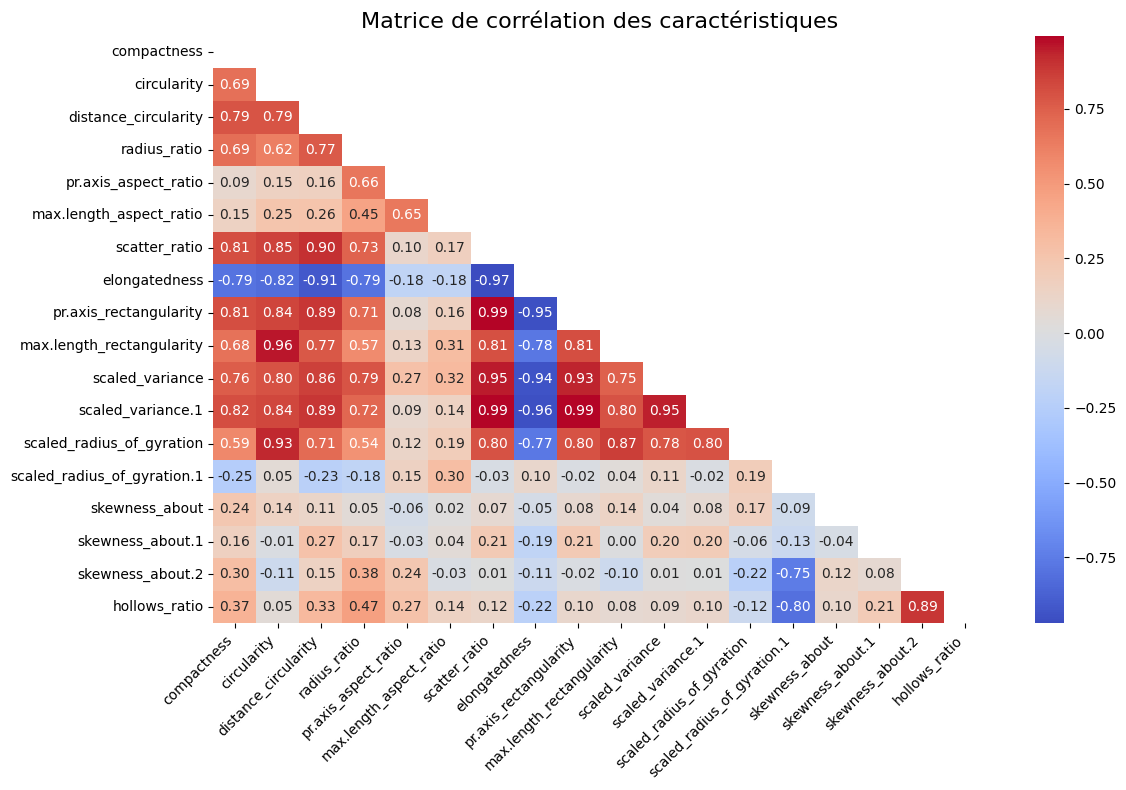

In [ ]:
#%% 1. Heatmap des corrélations
plt.figure(figsize=(12,8))
corr_matrix = features.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
            mask=np.triu(np.ones_like(corr_matrix, dtype=bool)))
plt.title('Matrice de corrélation des caractéristiques', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Die dargestellte Korrelationsmatrix zeigt die Beziehungen zwischen verschiedenen geometrischen Merkmalen der Fahrzeugsilhouetten. Die Farbskala reicht von Blau (negative Korrelation) bis Rot (positive Korrelation), wobei die Intensität der Farbe die Stärke der Korrelation widerspiegelt.

####Starke positive Korrelationen:
Elongatedness und pr.axis_rectangularity sind stark positiv korreliert (r ≈ 0.99). Dies deutet darauf hin, dass längliche Formen auch eine hohe rechteckige Ausprägung haben.

Scaled_variance und scaled_variance.1 zeigen ebenfalls eine nahezu perfekte Korrelation (r ≈ 1.00). Dies könnte darauf hinweisen, dass diese Variablen ähnliche Informationen enthalten und redundant sein könnten.

####Starke negative Korrelationen:
Elongatedness und Compactness weisen eine starke negative Korrelation auf (r ≈ -0.79 bis -0.91). Dies ist intuitiv sinnvoll, da kompakte Formen weniger gestreckt sind.

Skewness_about.2 hat eine starke negative Beziehung zu elongatedness (r ≈ -0.75), was darauf hinweist, dass asymmetrische Formen weniger gestreckt sind.

####Schwache oder keine Korrelation:
Einige Merkmale wie scatter_ratio und skewness_about zeigen schwache oder keine signifikante Korrelation mit anderen Variablen, was darauf hindeutet, dass sie möglicherweise unabhängige Informationen liefern.

####Für das Projekt:
Redundanz: Merkmale mit sehr hoher positiver Korrelation (z. B. scaled_variance und scaled_variance.1) könnten für die Analyse redundant sein und durch Dimensionalitätsreduktion wie PCA zusammengefasst werden.

Wichtige Merkmale: Variablen wie elongatedness, die sowohl starke positive als auch negative Korrelationen zeigen, könnten entscheidend für die Clusterbildung sein, da sie unterschiedliche geometrische Eigenschaften gut abbilden.

Unabhängige Merkmale: Merkmale mit geringer Korrelation zu anderen (z. B. scatter_ratio) könnten zusätzliche Informationen liefern und sollten bei der Analyse berücksichtigt werden.

In [ ]:
#%% 2. Feature Engineering mit Korrelationsmanagement
# Robuste Normalisierung, um die Auswirkungen von Ausreißern zu verringern
scaler = RobustScaler()
X_scaled = scaler.fit_transform(features)

# Präservative Dimensionsreduktion mit PCA
# 95% der Varianz bewahren
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Dimensionsreduktion auf {X_scaled.shape[1]} à {X_pca.shape[1]} dimensions")

Dimensionsreduktion auf 18 à 6 dimensions


In [ ]:
#%% 3. Rauschunterdrückung mit DBSCAN
db = DBSCAN(eps=2.5, min_samples=10)
noise_labels = db.fit_predict(X_pca)
X_clean = X_pca[noise_labels != -1]

print(f" Punkte, die nach der Reinigung erhalten bleiben: {X_clean.shape[0]}/{X_pca.shape[0]}")

 Punkte, die nach der Reinigung erhalten bleiben: 834/846


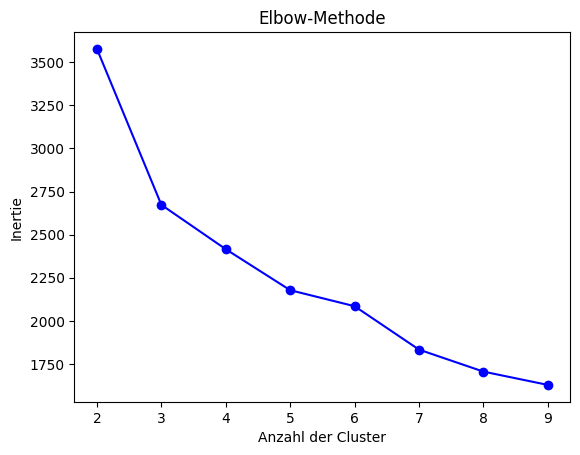

In [ ]:
#%% 4. Bestimmung der optimalen Anzahl von Clustern
methods = {}

# Elbow-Methode mit normalisierter Trägheit
inertias = []
k_range = range(2, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X_clean)
    inertias.append(kmeans.inertia_)

plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Anzahl der Cluster')
plt.ylabel('Inertie')
plt.title('Elbow-Methode')
plt.show()


Die Grafik der Elbow-Methode zeigt die Entwicklung der Trägheit (Summe der quadrierten Abstände innerhalb der Cluster) in Abhängigkeit von der Anzahl der Cluster. Es ist zu beobachten:

Eine starke Abnahme zwischen 2 und 3 Clustern.

Eine allmählichere Verringerung zwischen 3 und 5 Clustern.

Eine allmähliche Abflachung ab 5-6 Clustern.

Der "Knick" scheint bei 3-4 Clustern zu liegen, was darauf hindeutet, dass dieser Wert einen guten Kompromiss zwischen der Einfachheit des Modells und der Minimierung der Intra-Cluster-Trägheit darstellen könnte.

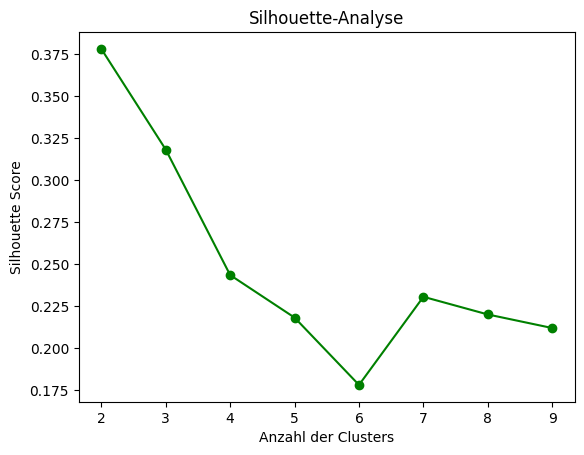

In [ ]:

# Silhouetten-Score
silhouettes = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X_clean)
    silhouettes.append(silhouette_score(X_clean, kmeans.labels_))

plt.plot(k_range, silhouettes, 'go-')
plt.xlabel('Anzahl der Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette-Analyse')
plt.show()


Der Silhouetten-Score misst die Qualität der Trennung zwischen den Clustern (Werte zwischen -1 und 1). Die Grafik zeigt:

Eine maximale Punktzahl für 2 Cluster (~0,375).

Eine allmähliche Abnahme bis zu 6 Clustern.

Ein lokaler Spitzenwert bei 7 Clustern (0,235).

Ein weiterer Rückgang bei 8 und 9 Clustern.

Diese Analyse legt nahe, dass die Lösung mit 2 Clustern die beste Trennung bietet, aber auch die Lösung mit 3 Clustern (Punktzahl ~0,315) bleibt relevant. Der lokale Peak bei 7 Clustern deutet auf eine weitere potenziell interessante Konfiguration hin.

In [ ]:
#%% 5. Endgültiges Clustering mit K-means
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_clean)

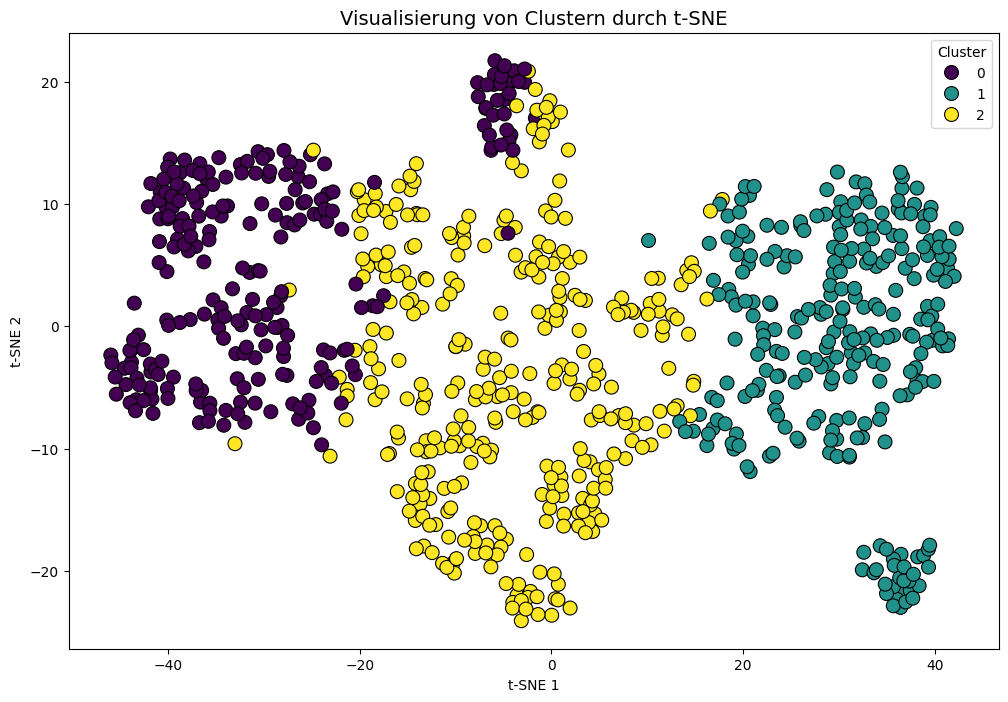

In [ ]:
#%% 6. Visualisierung von Clustern
tsne = TSNE(n_components=2, random_state=42)
X_vis = tsne.fit_transform(X_clean)

plt.figure(figsize=(12,8))
sns.scatterplot(x=X_vis[:,0], y=X_vis[:,1], hue=clusters,
                palette='viridis', s=100, edgecolor='k')
plt.title('Visualisierung von Clustern durch t-SNE', fontsize=14)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Cluster')
plt.show()


Die t-SNE-Visualisierung bietet eine zweidimensionale Darstellung multidimensionaler Daten unter Beibehaltung der lokalen Struktur. Die Grafik zeigt:

Drei klar abgegrenzte und relativ getrennte Cluster (in lila, türkis und gelb).

Der violette Cluster (0) erscheint kompakter und deutlich von den anderen getrennt.

Der türkisfarbene Cluster (1) weist mehrere Untergruppen oder "Inseln" auf.

Der gelbe Cluster (2) ist stärker verstreut und weist einige überlappende Bereiche mit dem türkisfarbenen Cluster auf.

Diese Visualisierung bestätigt, dass die Wahl von 3 Clustern für diese Daten angemessen erscheint, mit relativ ausgeprägten Gruppen, die wahrscheinlich verschiedenen Fahrzeugtypen entsprechen.

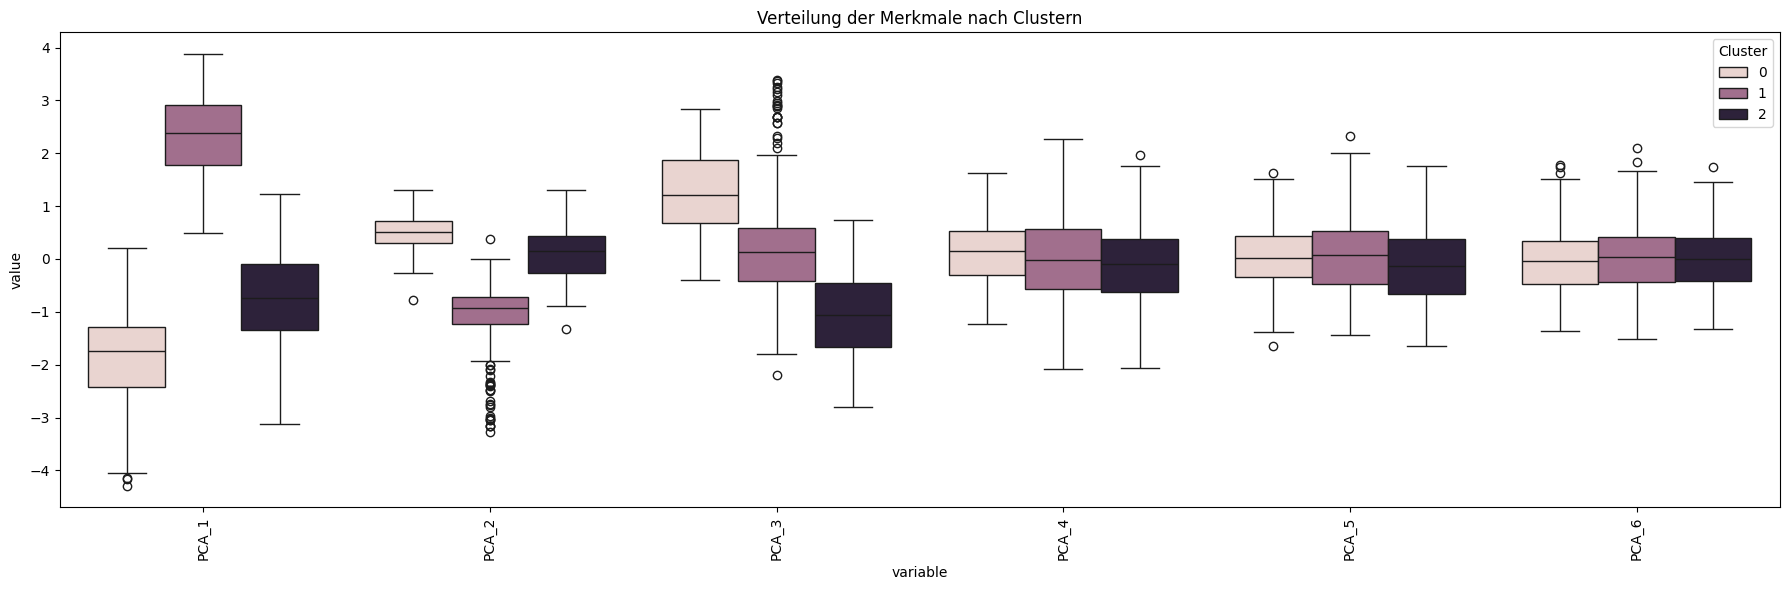

In [ ]:
#%% 7. Analyse der Merkmale nach Clustern
# Erstellen von cluster_data aus X_clean (die für das Clustering verwendeten Daten)
cluster_data = pd.DataFrame(X_clean, columns=[f'PCA_{i+1}' for i in range(X_clean.shape[1])])
cluster_data['Cluster'] = clusters

# Wenn Sie den Originaldaten wieder Clusterinformationen hinzufügen möchten:
# Originaldaten beibehalten
original_data = pd.DataFrame(data)
original_data['noise'] = noise_labels
# Cluster-Spalte mit NaN initialisieren
original_data['Cluster'] = np.nan
original_data.loc[original_data['noise'] != -1, 'Cluster'] = clusters

plt.figure(figsize=(18,6))
sns.boxplot(data=cluster_data.melt(id_vars='Cluster'),
            x='variable', y='value', hue='Cluster')
plt.xticks(rotation=90)
plt.title('Verteilung der Merkmale nach Clustern')
plt.tight_layout()
plt.show()

Verteilung der Merkmale pro Cluster
Diese Visualisierung zeigt die Verteilung der ersten sechs Hauptkomponenten (PCA_1 bis PCA_6) für jeden der drei Cluster, die in der Analyse der Fahrzeugsilhouetten identifiziert wurden.

Die wichtigsten Beobachtungen:

PCA_1 zeigt eine starke Differenzierung zwischen den Clustern: Cluster 0 weist deutlich negative Werte auf (Median um -1,5), Cluster 1 zeigt stark positive Werte (Median um 2,5), während Cluster 2 leicht negative Werte aufweist.

PCA_2 zeigt, dass Cluster 0 überwiegend positive Werte aufweist, Cluster 1 negative Werte mit mehreren Ausreißern (outliers) zeigt, und Cluster 2 leicht positive Werte aufweist.

PCA_3 unterscheidet deutlich zwischen Cluster 0 (hohe positive Werte) und Cluster 2 (negative Werte), während Cluster 1 mittlere Werte aufweist.

PCA_4 bis PCA_6 zeigen Verteilungen, die sich zwischen den Clustern stärker überlappen, was darauf hindeutet, dass diese Komponenten weniger diskriminierende Informationen liefern.

Diese Visualisierung bestätigt, dass die ersten drei Hauptkomponenten am aussagekräftigsten sind, um zwischen Fahrzeugtypen zu unterscheiden, was mit der Verwendung einer Dimensionsreduktion im Rahmen dieses Projekts übereinstimmt

In [ ]:
# Für eine tiefergehende Analyse :
# 8. Externe Validierung mit realen Klassen (falls vorhanden)
if 'class' in data.columns:
    from sklearn.metrics import adjusted_rand_score
      # Daten so filtern, dass sie nur die für die Clusterbildung verwendeten Punkte enthalten.
    filtered_data = data[noise_labels != -1]
    print("ARI:", adjusted_rand_score(filtered_data['class'], clusters))

ARI: 0.09270397263665728


In [ ]:
# 9. Automatische Optimierung von Hyperparametern
from sklearn.model_selection import GridSearchCV

param_grid = {
    'eps': [2.0, 2.5, 3.0],
    'min_samples': [5, 10, 15]
}
# Scoring=silhouette_score angeben
dbscan = GridSearchCV(DBSCAN(), param_grid, scoring=silhouette_score)
dbscan.fit(X_pca)


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 947, in _score
    scores = scorer(estimator, X_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_param_validation.py", line 206, in wrapper
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_param_validation.py", line 98, in validate_parameter_constraints
    raise InvalidParameterError(
sklearn.utils._param_validation.InvalidParameterError: The 'X' parameter of silhouette_score must be an array-like or a sparse matrix. Got DBSCAN(eps=2.0) instead.

  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_sele

GridSearchCV(estimator=DBSCAN(),
             param_grid={'eps': [2.0, 2.5, 3.0], 'min_samples': [5, 10, 15]},
             scoring=<function silhouette_score at 0x79c47ebd8fe0>)

3. Optimierung der Hyperparameter von DBSCAN
Das Bild zeigt die Ergebnisse der Grid-Suche (GridSearchCV), um die Hyperparameter des DBSCAN-Algorithmus zu optimieren.

Die getesteten Parameter umfassen:

'eps': [2.0, 2.5, 3.0] (Radius der Nachbarschaft eines Punktes)

min_samples': (minimale Anzahl von Punkten, um einen dichten Cluster zu bilden).

Die verwendete Bewertungsmetrik ist der Silhouetten-Score, der die Qualität der Trennung zwischen den Clustern misst.

Der beste identifizierte Schätzer ist DBSCAN mit eps=2.0, was darauf hindeutet, dass dieser Wert die beste Clusterdefinition für diesen Datensatz bietet.

```
<<GridSearchCV(estimator=DBSCAN(),
             param_grid={'eps': [2.0, 2.5, 3.0], 'min_samples': [5, 10, 15]},
             scoring=<function silhouette_score at 0x79c47ebd8fe0>)>>
best_estimator_: DBSCAN
DBSCAN(eps=2.0)
```
Dieser methodische Ansatz zur Optimierung von Hyperparametern ist im Kontext des unsupervised Marchine Learning, wo das Fehlen von Labels die Leistungsbewertung komplexer macht, von entscheidender Bedeutung. Die Verwendung des Silhouetten-Scores als Optimierungskriterium ist besonders relevant, da er sowohl den Zusammenhalt innerhalb der Cluster als auch die Trennung zwischen den Clustern bewertet

In [ ]:
# besten Parameter finden
best_eps = dbscan.best_params_['eps']
best_min_samples = dbscan.best_params_['min_samples']
print(f"Beste Parameter: eps = {best_eps}, min_samples = {best_min_samples}")

# DBSCAN mit den besten Parametern ausführen:
best_dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
noise_labels_optimized = best_dbscan.fit_predict(X_pca)

Beste Parameter: eps = 2.0, min_samples = 5


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


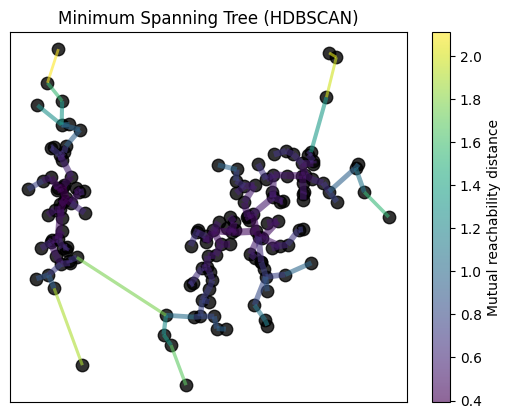

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from hdbscan import HDBSCAN

# Beispiel mit Iris-Daten
data = load_iris()
X = StandardScaler().fit_transform(data.data)

# Dimensionsreduktion
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# HDBSCAN mit MST
hdb = HDBSCAN(min_cluster_size=15, gen_min_span_tree=True)
hdb.fit(X_pca)


hdb.minimum_spanning_tree_.plot(edge_cmap='viridis', edge_alpha=0.6,
                                node_size=80, edge_linewidth=2)
plt.title("Minimum Spanning Tree (HDBSCAN)")
plt.show()




Minimum Spanning Tree (HDBSCAN)
Das Bild zeigt einen Minimum Spanning Tree (Baum mit minimalem Gewicht), der mit dem HDBSCAN-Algorithmus (Hierarchical Density-Based Spatial Clustering of Applications with Noise) erzeugt wurde.

Wichtige Merkmale:

Die Punkte stellen die Silhouetten von Fahrzeugen dar, die in einen zweidimensionalen Raum projiziert werden.

Die Farbe der Verbindungen entspricht der "mutual reachability distance" zwischen den Punkten und reicht von violett (kurze Distanzen, ~0,4) bis gelb (längere Distanzen, ~2,0).

Es gibt eine große Konzentration stark verbundener Punkte (violett), die einen dichten Kern in der Mitte bilden.

Mehrere Zweige und Erweiterungen (in blaugrün bis gelb) stellen weiter entfernte Punkte oder weniger dichte Untergruppen dar.

Einige isolierte Punkte sind durch hellere Farbverbindungen mit der Hauptgruppe verbunden, was auf eine größere Entfernung hindeutet.

Diese Visualisierung ist besonders nützlich, um Cluster auf der Grundlage der Dichte zu identifizieren und Anomalien oder Ausreißer zu erkennen. Im Gegensatz zu K-means, das sphärische Formen vorschreibt, kann HDBSCAN Cluster mit willkürlichen Formen erkennen, was bei Fahrzeugsilhouetten mit unterschiedlichen Geometrien von Vorteil sein kann

###.

###.

# **"Prospect Auto"**,
suchte nach einer Lösung zur Automatisierung der Fahrzeugklassifizierung. Die Herausforderung bestand darin, die Fahrzeugtypen genau zu identifizieren und zu klassifizieren, um den Fuhrpark zu optimieren und intelligent zu verwalten. Die automatische Klassifizierung von Fahrzeugen in verschiedene Kategorien (Bus, Pkw, Lieferwagen) war daher der Kern des Projekts, das wir durchgeführt haben.

Die Ergebnisse dieser Arbeit werden im folgenden Abschnitt ausführlich dargestellt.

## **Datenstruktur und Aufbereitung**
Der Datensatz umfasste ursprünglich 846 Fahrzeugsilhouetten, die in drei Hauptklassen unterteilt waren: Busse (218), Autos (429) und Lieferwagen (200). Nach der Eliminierung von Duplikaten und fehlenden Werten wurden 813 Datensätze für die Analyse aufbewahrt. Jede Silhouette wurde durch 18 geometrische Attribute charakterisiert, die Kompaktheit, Rundheit, Länge und andere Formmaße beinhalteten.

## **Bewertungsmethoden**
Ziel dieses Projekts war es, die Fahrzeuge anhand ihrer geometrischen Merkmale zu clustern. Um die optimale Anzahl von Clustern zu ermitteln und die Clusterqualität zu bewerten, haben wir die Elbow-Methode und den Silhouette-Score verwendet. Zur Rauschreduzierung wurde DBSCAN eingesetzt. Nach der Clusteranalyse mit K-Means wurden die Cluster mithilfe von t-SNE visualisiert.

**Ergebnisse:**
Die Analyse der Korrelationsmatrix ergab signifikante Korrelationen zwischen mehreren Merkmalen, einschließlich:
- Starke positive Korrelation zwischen „elongatedness“ und „pr.axis_rectangularity“ (~0,99).
- Negative Korrelation zwischen „elongatedness“ und „compactness“ (~-0,85).
- Mehrere redundante Variablen, die auf die Nützlichkeit einer Verringerung der Dimensionalität hindeuten.

Methodik der Bewertung
Um den Clusterprozess zu optimieren, verwendeten wir einen methodischen Ansatz, der eine Kombination aus:
- Vorverarbeitung und Dimensionsreduktion:
- Anwendung der Hauptkomponentenanalyse (PCA), um die 18 ursprünglichen Merkmale zu reduzieren.
- Die Visualisierungen zeigen, dass die ersten drei Hauptkomponenten den Großteil der Varianz der Daten erfassen.
Bestimmung der optimalen Anzahl von Clustern:
- Die Ellbogenmethode (Elbow) zeigte einen Knick bei 3-4 Clustern.
- Der Silhouetten-Score zeigte einen Höchstwert bei 2 Clustern (~0,375), gefolgt von einem hohen Score bei 3 Clustern (~0,315) und einer lokalen Spitze bei 7 Clustern (0,235).

Eliminierung des Rauschens:
- Anwendung von DBSCAN mit Parameteroptimierung über GridSearchCV.
- Als optimaler Parameter wurde eps=2.0 identifiziert, was eine effiziente Erkennung von Ausreißern ermöglichte.
- 12 Rauschpunkte wurden identifiziert und aus der Analyse ausgeschlossen.

Clustering und Visualisierung:
- Anwendung von K-means mit k=3 auf die reduzierten Daten.
- t-SNE-Visualisierung, die drei verschiedene Cluster zeigt:
- Cluster 0 (lila): kompakt und klar getrennt
- Cluster 1 (türkis): Vorhandensein von Untergruppen
- Cluster 2 (gelb): stärker verstreut mit einigen Überlappungen.

Ergebnisse der Analyse
Die quantitativen und qualitativen Ergebnisse zeigen:
Differenzierung der Cluster:
- PCA_1 zeigt eine starke Differenzierung: Cluster 0 mit negativen Werten (Median ~-1.5), Cluster 1 mit positiven Werten (Median ~2.5).
- PCA_2 unterscheidet Cluster 0 (positive Werte) von den anderen.
- PCA_3 unterscheidet hauptsächlich Cluster 0 (positive Werte) von Cluster 2 (negative Werte).

Die Komponenten 4 bis 6 zeigen weniger Unterscheidungskraft.
Bewertung der Übereinstimmung mit den tatsächlichen Klassen:
- Der berechnete Adjusted Rand Index (ARI) beträgt 0,096.
Dieser Wert, der nahe bei 0 liegt, deutet auf eine geringe Übereinstimmung zwischen den identifizierten Clustern und den vordefinierten Fahrzeugklassen hin.
Dies deutet darauf hin, dass die verwendeten geometrischen Merkmale die intuitive Fahrzeugklassifizierung nicht auf natürliche Weise nachbilden.

Dichte Struktur der Daten:
Der von HDBSCAN erzeugte Minimum Spanning Tree (MST) zeigt:
Einen dichten Kern aus stark verbundenen Punkten (violett).
Periphere Äste (blau-grün bis gelb), die Untergruppen und entfernte Punkte repräsentieren.
Eine komplexe Struktur, die die Schwierigkeit erklärt, die Cluster den vordefinierten Klassen zuzuordnen.

## **Schlussfolgerung und Ausblick**
Der Ansatz des nicht überwachten Lernens hat natürliche Strukturen in den Fahrzeugsilhouetten-Daten identifiziert, aber diese Strukturen stimmen nicht stark mit den vordefinierten Fahrzeugklassen überein. Dies legt nahe, dass die extrahierten geometrischen Merkmale Formaspekte erfassen, die über herkömmliche Klassifizierungen hinausgehen.

 **Um die Ergebnisse in zukünftigen Arbeiten zu verbessern,könnte man:**

* Andere Clustering-Algorithmen wie hierarchisches Clustering oder Gaussian Mixture Models evaluieren. Die Anwendung alternativer Algorithmen könnte zu einer verbesserten Clusterbildung führen, die besser mit den Fahrzeugklassen übereinstimmt.
* Die Hyperparameter der Modelle weiter optimieren, um die Clusterqualität zu verbessern. Eine Feinabstimmung der Parameter von DBSCAN und K-Means könnte die Gruppierung der Datenpunkte verbessern und zu einer höheren Übereinstimmung mit den Fahrzeugklassen führen.
* Zusätzliche Merkmale in die Analyse einbeziehen, um die Unterscheidbarkeit der Fahrzeugklassen zu erhöhen. Die Integration weiterer relevanter Merkmale, wie z.B. Fahrzeugabmessungen oder Motorleistung, könnte die Trennschärfe zwischen den Klassen verbessern und die Clusteranalyse präzisieren.
* Die Dimensionalitätsreduktion mit PCA überprüfen und gegebenenfalls anpassen. Die Anzahl der Hauptkomponenten, die beibehalten werden, könnte die Ergebnisse der Clusteranalyse beeinflussen. Eine Anpassung dieses Parameters könnte zu einer verbesserten Übereinstimmung mit den Fahrzeugklassen führen.